# 1.1.9 Example: Harvest Quotas

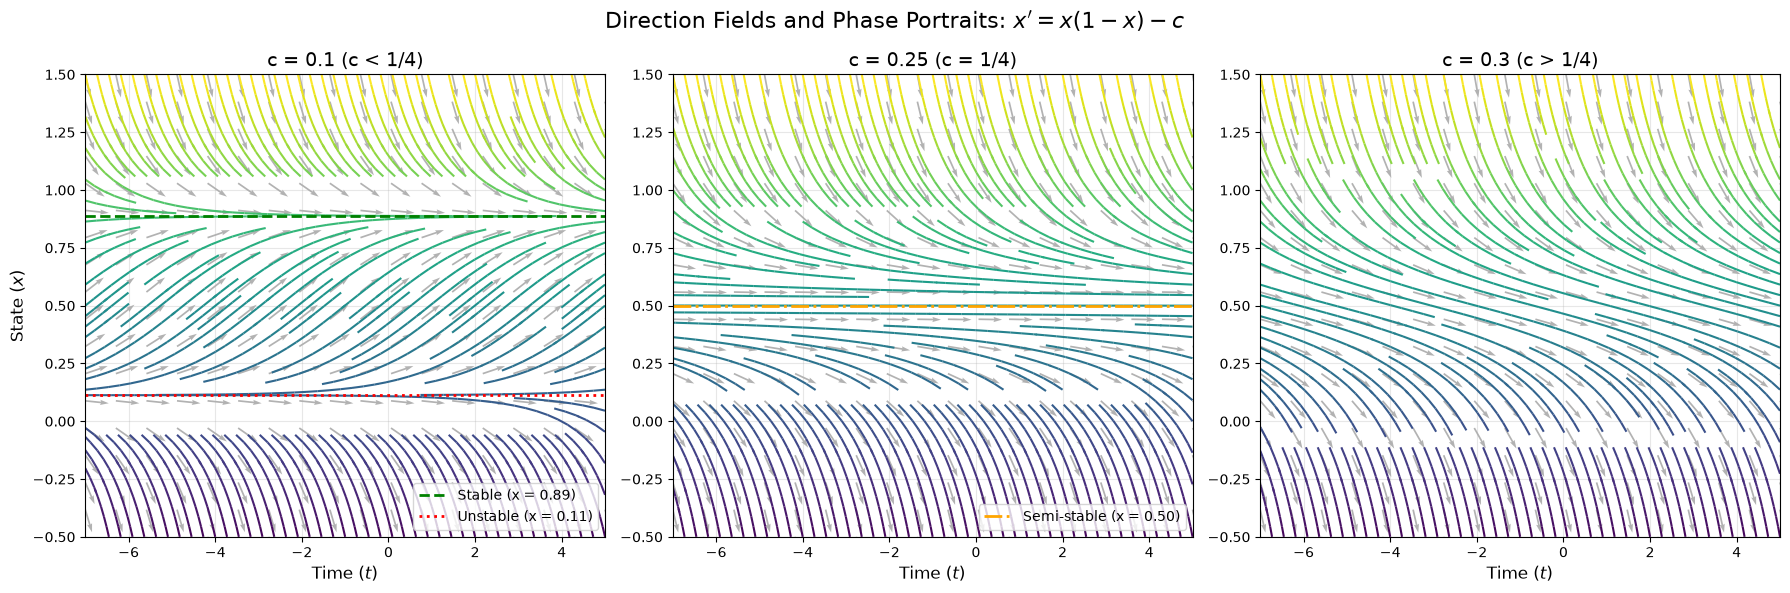

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grid configuration for vector field
t = np.linspace(-7, 5, 18)
x = np.linspace(-0.5, 1.5, 18)
T, X = np.meshgrid(t, x)

c_values = [0.1, 0.25, 0.3]
titles = ["c = 0.1 (c < 1/4)", "c = 0.25 (c = 1/4)", "c = 0.3 (c > 1/4)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, c in enumerate(c_values):
    ax = axes[i]
    
    # 2. ODE Vectors Components: x' = x(1 - x) - c
    dT = np.ones_like(T)  # Time's variation is uniform
    dX = X * (1 - X) - c
    
    # Normalization for all vectors that has equal sizes
    magnitude = np.sqrt(dT**2 + dX**2)
    dT_norm = dT / magnitude
    dX_norm = dX / magnitude
    
    # Direction field (setas)
    ax.quiver(T, X, dT_norm, dX_norm, color='gray', alpha=0.6,
               angles='xy', scale=22)
    
    # 3. Preparation of integral curves using streamplot (linhas densas e contínuas)
    t_fine = np.linspace(-7, 5, 150)
    x_fine = np.linspace(-0.5, 1.5, 150)
    T_fine, X_fine = np.meshgrid(t_fine, x_fine)
    dT_fine = np.ones_like(T_fine)
    dX_fine = X_fine * (1 - X_fine) - c
    
    # streamplot para gerar a sensação de "fluxo contínuo"
    # arrowstyle='-' retira as flechas das linhas azuis, mantendo-as contínuas
    # color=X_fine cria um efeito de mapa de cores
    strm = ax.streamplot(T_fine, X_fine, dT_fine, dX_fine, color=X_fine, cmap='viridis', density=1.5, linewidth=1.5, arrowstyle='-')
    
    # Balance Lines (Where x' = 0)
    if c < 0.25:
        eq1 = 0.5 + np.sqrt(0.25 - c)
        eq2 = 0.5 - np.sqrt(0.25 - c)
        ax.axhline(eq1, color='green', linestyle='--', linewidth=2, label=f'Stable (x = {eq1:.2f})')
        ax.axhline(eq2, color='red', linestyle=':', linewidth=2, label=f'Unstable (x = {eq2:.2f})')
    elif c == 0.25:
        eq = 0.5
        ax.axhline(eq, color='orange', linestyle='-.', linewidth=2, label=f'Semi-stable (x = {eq:.2f})')
        
    # Additional visual configurations
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("Time ($t$)", fontsize=12)
    if i == 0:
        ax.set_ylabel("State ($x$)", fontsize=12)
    ax.set_xlim(-7, 5)
    ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)
    if c <= 0.25:
        ax.legend(loc='lower right')

plt.suptitle("Direction Fields and Phase Portraits: $x' = x(1-x) - c$", fontsize=16)
plt.tight_layout()
plt.show()